<a href="https://colab.research.google.com/github/kunalssharma125-pixe/machinelearning1/blob/main/ML_PROJECT_HOUSE_PRICE_PREDICTION_Project%20demo%201%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
 #📦 BASIC LIBRARIES
import numpy as np   # Used for numerical operations (arrays, calculations)
import pandas as pd  # Used to load and handle dataset (CSV files, tables)

# 📊 VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt  # Used to create basic graphs (line, bar, histogram)
import seaborn as sns            # Used for advanced visualization (heatmaps, correlations)

# 🧹 DATA PREPROCESSING
from sklearn.model_selection import train_test_split

# Used to split dataset into training and testing data
from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder → converts categorical data (text) into numerical form
# StandardScaler → scales data so all values are in similar range

from sklearn.impute import SimpleImputer
# Used to handle missing values (fill NaN with mean/median/most frequent)

# 🤖 MACHINE LEARNING MODELS
from sklearn.linear_model import LinearRegression
# Simple regression model to predict continuous values (like price)

from sklearn.ensemble import RandomForestRegressor
# Advanced model using multiple decision trees for better accuracy

# 📈 MODEL EVALUATION
from sklearn.metrics import mean_squared_error, r2_score
# mean_squared_error → checks error between predicted and actual values
# r2_score → tells how well the model fits the data (accuracy measure)


Load Dataset

In [4]:
df = pd.read_csv("House Price Prediction Dataset.csv")

BASIC CHECK

In [5]:
df.head()     # view data
df.info()     # check data types & missing value
df.isnull()   # CHECK THAT IS THERE ANY NULL VALUE IN DATA OR NOT

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False,False,False


DROP UNNECESSARY COLUMN

In [6]:
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

HANDLE MISSING VALUES

In [7]:
# Fill numerical columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns with most frequent value
df.fillna(df.mode().iloc[0], inplace=True)

Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

Remove Duplicates

In [9]:
df.drop_duplicates(inplace=True)

Encode Categorical Data

In [11]:
# Encode manually using Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = le.fit_transform(df['Garage'])
df['Location'] = le.fit_transform(df['Location'])

print("After Encoding:")
print(df.head())

After Encoding:
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  Garage  \
0  1360         5          4       3       1970         0          0       0   
1  4272         5          4       3       1958         0          0       0   
2  3592         2          2       3       1938         0          2       0   
3   966         4          2       2       1902         2          1       1   
4  4926         1          4       2       1975         0          1       1   

    Price  
0  149919  
1  424998  
2  266746  
3  244020  
4  636056  


FEATURE & TARGET SEPARATION

In [13]:
X = df.drop('Price', axis=1)
y = df['Price']

# Check
print("Features:\n", X.head())
print("Target:\n", y.head())

Features:
    Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  Garage
0  1360         5          4       3       1970         0          0       0
1  4272         5          4       3       1958         0          0       0
2  3592         2          2       3       1938         0          2       0
3   966         4          2       2       1902         2          1       1
4  4926         1          4       2       1975         0          1       1
Target:
 0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64


Verification

In [14]:
print(X.shape)
print(y.shape)

(2000, 8)
(2000,)


RANDOM FOREST REGRESSOR

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)   # training

y_pred = rf.predict(X_test)   # prediction

MODEL EVALUATION

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 86157199403.32457
R2 Score: -0.10743569077376658


Compare Actual vs Predicted

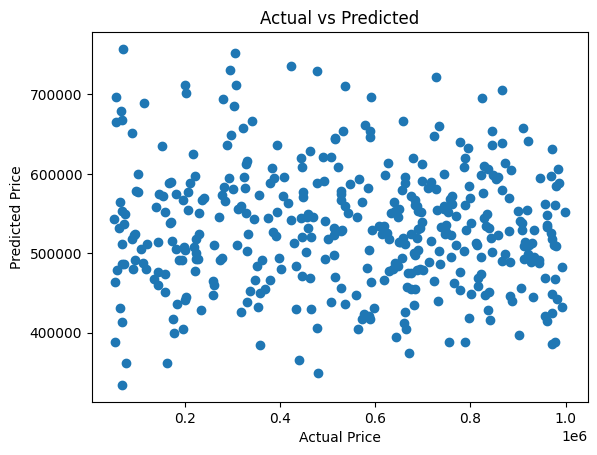

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

Feature Importance

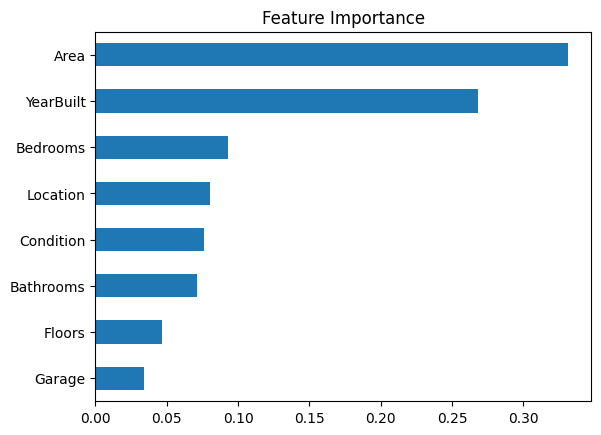

In [21]:
import pandas as pd

importance = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

Error Comparison

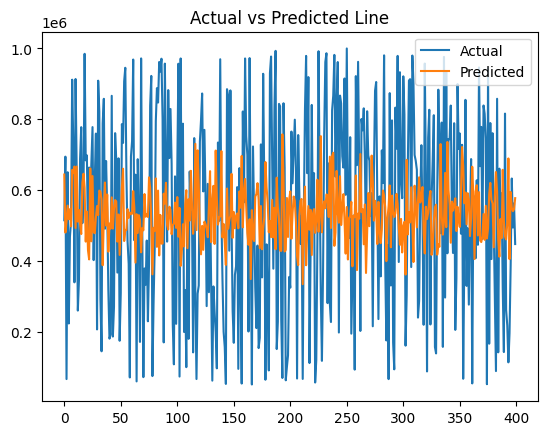

In [22]:
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Line")
plt.show()

FOR CONFUSION MATRICE CONVERTING PRICE INTO CATEGORIES

In [23]:
# Convert price into categories
df['Price_Category'] = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Price_Category'] = le.fit_transform(df['Price_Category'])

using classification model :

In [25]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(['Price', 'Price_Category'], axis=1)
y = df['Price_Category']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Confusion Matrix:

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[41 53 40]
 [49 36 46]
 [54 46 35]]


Confusion Matrix Heatmap

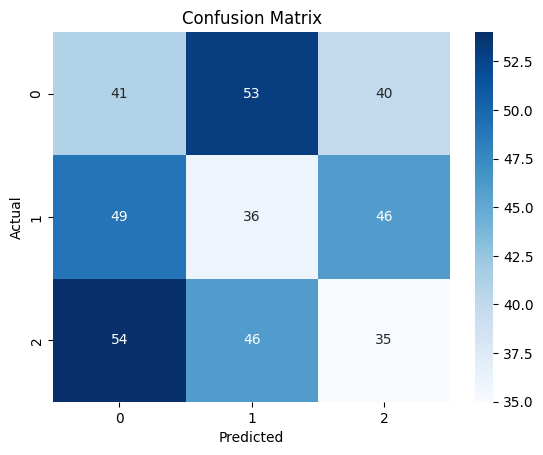

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.28      0.31      0.29       134
           1       0.27      0.27      0.27       131
           2       0.29      0.26      0.27       135

    accuracy                           0.28       400
   macro avg       0.28      0.28      0.28       400
weighted avg       0.28      0.28      0.28       400

